# CGC-graded comics as an asset class — a quantitative teardown 🔬
### Comic index vs SPY (CAGR / vol / MDD + an annual-excess *t*) · Newey-West proxy alpha · the CGC-grading + dealer-spread haircut on NAV · a synthetic bubble positive control

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Comics_beat_the_S%26P%3F: Busted](https://img.shields.io/badge/Comics_beat_the_S%26P%3F-Busted-8b949e?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb). We test the strongest tradable form of "CGC-graded key comics beat the S&P": (H₁) the graded-comic index out-returns SPY risk-adjusted; (H₂) the one buyable proxy carries alpha vs the market; (H₃) it survives the grading + transaction + carry cost of owning slabs. We find **H₁ rejected** (it *under*-performs), **H₂ rejected** (no significant alpha — and the proxy *lost money*), **H₃ rejected** (negative net of costs).

> ⚠️ **Not investment advice — data provenance.** The comic index is **hardcoded, cited, approximate** (public GoCollect / Heritage reporting — a *labelled proxy*, never the live feed, which is paywalled). The equity proxy `FNKO` and benchmark `SPY` are month-end Adj Close via yfinance (as-of 2025-12-31). Offline core + synthetic control are deterministic. Methods in [`docs/references.md`](../docs/references.md); numbers in [`docs/results.md`](../docs/results.md).
>
> 💡 **The `💡 In plain words` notes** translate each result back to intuition.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from comic_book_index import data, strategy as st

HAVE_PROXIES = data.have_proxies()
IDX = data.load_comic_index()                        # hardcoded, cited, APPROXIMATE proxy
PROX = data.load_proxies() if HAVE_PROXIES else None
print("equity-proxy cache present:", HAVE_PROXIES,
      "| comic-index years:", IDX.index[0].year, "->", IDX.index[-1].year)

# frozen headline numbers (mirror of docs/results.md)
R = {'win': '2018 → 2025', 'idx_levels': {2018: 100, 2019: 108, 2020: 130, 2021: 175, 2022: 158, 2023: 145, 2024: 150, 2025: 152}, 'idx_yoy': {2019: 8.0, 2020: 20.4, 2021: 34.6, 2022: -9.7, 2023: -8.2, 2024: 3.4, 2025: 1.3}, 'peak_date': '2022-01', 'peak_level': 188, 'rec_af15': 3.6, 'rec_ac1': 6.0, 'peak_trough': -20.2, 'idx_cagr': 6.16, 'idx_vol': 15.8, 'idx_sharpe': 0.45, 'idx_mdd': -17.1, 'spy_cagr_ye': 17.18, 'spy_vol_ye': 16.9, 'spy_mdd_ye': -18.2, 'excess_mean': -11.29, 'excess_t': -1.792, 'excess_p': 0.123, 'excess_n': 7, 'fnko_cagr': -8.04, 'fnko_vol': 66.9, 'fnko_sharpe': 0.24, 'fnko_mdd': -88.1, 'fnko_alpha': -5.08, 'fnko_beta': 1.44, 'fnko_t': -0.18, 'fnko_p': 0.858, 'fnko_n': 96, 'spy_cagr': 14.21, 'spy_vol': 16.5, 'spy_sharpe': 0.89, 'spy_mdd': -23.9, 'cost_gross': 6.16, 'cost_spread': -9.14, 'cost_grading': -0.67, 'cost_carry': -1.0, 'cost_net': -5.15, 'syn_peak': 460, 'syn_end': 135, 'syn_cagr': 5.19, 'syn_sharpe': 0.34, 'syn_mdd': -70.7}


equity-proxy cache present: True | comic-index years: 2018 -> 2025


## Verdict, up front

| Axis | Stamp | Decisive number |
|---|---|---|
| **Signal** | `NONE` | Comic index CAGR **6.2%** vs SPY **17.2%** (2018–2025); mean annual excess **-11.3%/yr**, *t* = **-1.79** (n=7, short of \|t\|≥2). Proxy FNKO: no significant alpha (NW *t*=-0.18) and a *negative* CAGR. |
| **Tradability** | `MIRAGE` | Gross index CAGR **+6.2%** → **NET -5.2%/yr** after a 25% dealer/auction spread + 2% CGC grading + 1%/yr carry. Only listed proxy FNKO: CAGR **-8.0%**, maxDD **-88%**, β≈1.4. Illiquid, high-carry, round-tripped. |
| **Comics beat the S&P?** | `BUSTED` | SPY wins CAGR (14.2 vs 6.2), drawdown (-18 vs -17 on the index; FNKO -88), and net-of-cost. Every column. |

> 💡 In plain words: the comic market under-performed stocks, the only thing you can buy is a money-losing toy stock, and the grading-and-selling frictions turn even the gross return negative. There is no axis on which "comics beat the S&P" survives.

## 1 · The claim, steelmanned

Let the graded-comic index level be $I_t$ and the benchmark $B_t$ (SPY). The claim is a joint hypothesis:

- **H₁ (it out-returns).** Annual excess $\;x_t = r^I_t - r^B_t\;$ has $\mathbb{E}[x_t] > 0$ with $t > 2$ — comics beat stocks *risk-adjusted*.
- **H₂ (it's buyable with alpha).** For a tradable proxy $P$, the intercept $\alpha$ in $r^P_t = \alpha + \beta r^B_t + \varepsilon_t$ is positive with a Newey-West *t* > 2.
- **H₃ (it survives carry).** The net CAGR after the CGC grading fee $f$, the dealer/auction round-trip spread $s$ over hold $h$, and annual carry $c$ stays positive.

The 2020–22 melt-up is the steelman: for ~18 months H₁ held *in-sample*. The test is whether it holds over the **full cycle, risk-adjusted, net of cost** — i.e. whether it's an asset class or a bubble.

## 2 · So what? — what rides on each answer

If H₁–H₃ held, graded comics would be a genuine diversifier: equity-beating return, collectible, low-correlation, inflation-proof — the exact pitch. But each leg is separately falsifiable. H₁ is a **return race** on a common clock. H₂ asks whether *any investable expression* delivers something beyond market beta — and here the honest finding is starker: there is essentially **no** listed expression at all (CGC, PSA and Heritage are private/delisted), so the "only buyable proxy" is a badly-fitting one (Funko). H₃ is the **microstructure tax**: a slab pays a CGC grading fee *and* a ~25% bid/ask round-trip *and* a multi-year insured hold, frictions an ETF never pays. The asset-class claim needs all three; failing any one downgrades it to a bubble narrative.

## 3 · How we'd know — the protocol

- **Comic index (proxy).** A hardcoded, cited, **approximate** annual level (base 100 @ 2018), reconstructed from public GoCollect / Heritage reporting (2020–21 melt-up; early-2022 top; a 2022–23 softening; a 2024–25 blue-chip stabilisation with Action #1 at a record ~$6.0M). *Labelled a proxy* — its path is defensible, its precise year-end values are not a live feed.
- **Equity proxy.** `FNKO` (Funko) and `SPY` month-end Adj Close (yfinance, cached). Survivorship is **not** a concern here (a named ticker, not a screen), but note the honest limitation: FNKO is a toy company, the *nearest* listed proxy only because the clean ones (CGC/PSA parents, Heritage) are private/delisted.
- **Signal test.** (i) Paired annual-excess $t$ of $r^I - r^B$ (small-$n$, weak by construction). (ii) **Newey-West (6-lag) HAC** $t$ of the proxy alpha vs SPY — the bar for `REAL` is *t* ≥ 2 in the comics' favour.
- **Cost (beat 6).** Charge a ~2% CGC grading fee + a 25% dealer/auction round-trip spread (over a 3y hold) + 1%/yr carry **once on NAV**; net CAGR.
- **Positive control.** A deterministic bubble-and-round-trip path with a *planted* boom/bust drift; the engine must recover the up-sign and a finite Sharpe — proof a null on the real tape is a real null, not a broken harness.
- **What would make us say "asset class":** H₁ *t* > 2 **or** a proxy alpha *t* > 2, **and** a positive net-of-cost CAGR. We find none of these.

## 4 · The teardown

### 4a · The race — comic index vs SPY, risk-adjusted

Year-end levels rebased to \$100, both series on one clock. CAGR, vol and max-drawdown in the print.

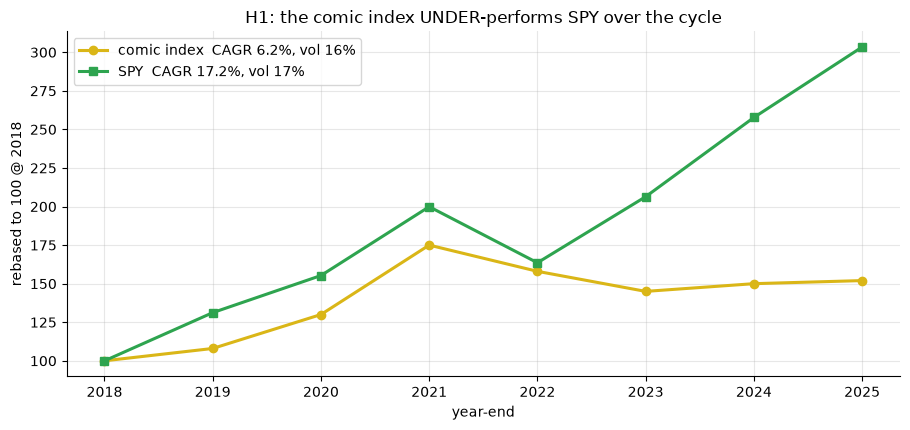

index: CAGR 6.16%  vol 15.8%  maxDD -17.1%
SPY  : CAGR 17.18%  vol 16.9%  maxDD -18.2%
annual excess (idx-SPY): mean -11.29%/yr  t=-1.792  (n=7)


In [2]:
yrs = list(R['idx_levels'].keys())
lv = np.array([float(IDX.loc[f'{y}-12-31']) for y in yrs])
if HAVE_PROXIES:
    spy_ye = PROX['SPY'].resample('YE').last()
    spy_ye = spy_ye[(spy_ye.index.year>=2018)&(spy_ye.index.year<=2025)]
    spy = (spy_ye/spy_ye.iloc[0]*100).values; sx=[d.year for d in spy_ye.index]
    si = st.summarize(IDX, periods_per_year=1.0)
    ss = st.summarize(spy_ye, periods_per_year=1.0)
    ae = st.annual_excess_t(IDX, PROX['SPY'])
else:
    spy = np.array([100*(1+R['spy_cagr_ye']/100)**(y-2018) for y in yrs]); sx=yrs
    si={'cagr':R['idx_cagr']/100,'vol':R['idx_vol']/100,'mdd':R['idx_mdd']/100}
    ss={'cagr':R['spy_cagr_ye']/100,'vol':R['spy_vol_ye']/100,'mdd':R['spy_mdd_ye']/100}
    ae={'mean_excess':R['excess_mean']/100,'t':R['excess_t'],'n':R['excess_n']}
fig, ax = plt.subplots(figsize=(9.2, 4.4))
ax.plot(yrs, lv, 'o-', c=AMBER, lw=2.2, label=f"comic index  CAGR {si['cagr']*100:.1f}%, vol {si['vol']*100:.0f}%")
ax.plot(sx, spy, 's-', c=GREEN, lw=2.2, label=f"SPY  CAGR {ss['cagr']*100:.1f}%, vol {ss['vol']*100:.0f}%")
ax.set_xlabel('year-end'); ax.set_ylabel('rebased to 100 @ 2018')
ax.set_title('H1: the comic index UNDER-performs SPY over the cycle'); ax.legend()
plt.tight_layout(); plt.show()
print(f"index: CAGR {si['cagr']*100:.2f}%  vol {si['vol']*100:.1f}%  maxDD {si['mdd']*100:.1f}%")
print(f"SPY  : CAGR {ss['cagr']*100:.2f}%  vol {ss['vol']*100:.1f}%  maxDD {ss['mdd']*100:.1f}%")
print(f"annual excess (idx-SPY): mean {ae['mean_excess']*100:+.2f}%/yr  t={ae['t']:+.3f}  (n={ae['n']})")

> 💡 In plain words: the comic index compounds at **6.2%** against SPY's **17.2%** — it loses the race. The mean annual excess is **-11.3%/yr**, *t* = **-1.79** (n=7): the point estimate is a large negative, but with only 7 annual points it doesn't clear \|*t*\| ≥ 2 in *either* direction. Either way there is **no evidence of out-performance**. H₁ rejected; the honest stamp is `NONE`, leaning negative.

### 4b · The buyable proxy — is there alpha, or just (money-losing) beta?

Newey-West (6-lag) regression of Funko's **monthly** return on SPY. `REAL` needs $t_\alpha \ge 2$ in the comics' favour. (This is the *only* listed proxy — and a poor one — because the clean names are private/delisted.)

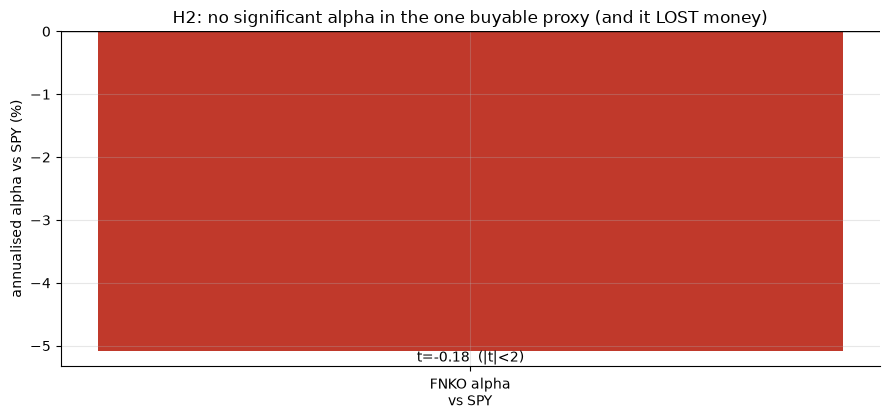

FNKO CAGR  -8.04%  Sharpe 0.24  maxDD  -88.1%  alpha -5.08%/yr  beta 1.44  NW t -0.18
SPY  CAGR  14.21%  Sharpe 0.89  maxDD  -23.9%


In [3]:
if HAVE_PROXIES:
    spy_r = PROX['SPY'].pct_change().dropna()
    s = st.summarize(PROX['FNKO']); nw = st.newey_west_alpha_t(PROX['FNKO'].pct_change().dropna(), spy_r, 6)
    row = dict(cagr=s['cagr']*100, sharpe=s['sharpe'], mdd=s['mdd']*100,
               alpha=nw['alpha_ann']*100, beta=nw['beta'], t=nw['t_alpha'])
    sp = st.summarize(PROX['SPY'])
    sprow = dict(cagr=sp['cagr']*100, sharpe=sp['sharpe'], mdd=sp['mdd']*100)
else:
    row = dict(cagr=R['fnko_cagr'],sharpe=R['fnko_sharpe'],mdd=R['fnko_mdd'],alpha=R['fnko_alpha'],beta=R['fnko_beta'],t=R['fnko_t'])
    sprow = dict(cagr=R['spy_cagr'],sharpe=R['spy_sharpe'],mdd=R['spy_mdd'])
fig, ax = plt.subplots(figsize=(9.0, 4.3))
labels=['FNKO alpha\nvs SPY']; alphas=[row['alpha']]
ax.bar(labels, alphas, .4, color=[GREEN if row['alpha']>0 else RED])
ax.axhline(0, c='k', lw=1); ax.set_ylabel('annualised alpha vs SPY (%)')
ax.annotate(f"t={row['t']:+.2f}  (|t|<2)",(0,row['alpha']),ha='center',va='bottom' if row['alpha']>=0 else 'top')
ax.set_title('H2: no significant alpha in the one buyable proxy (and it LOST money)')
plt.tight_layout(); plt.show()
print(f"FNKO CAGR {row['cagr']:6.2f}%  Sharpe {row['sharpe']:.2f}  maxDD {row['mdd']:6.1f}%  alpha {row['alpha']:+.2f}%/yr  beta {row['beta']:.2f}  NW t {row['t']:+.2f}")
print(f"SPY  CAGR {sprow['cagr']:6.2f}%  Sharpe {sprow['sharpe']:.2f}  maxDD {sprow['mdd']:6.1f}%")

> 💡 In plain words: Funko is **β≈1.4** beta with a **-5%/yr** (insignificant, *t*=-0.18) alpha, an **-88%** drawdown, and a *negative* CAGR — it amplified the bubble, it didn't hedge it. (Its Sharpe reads a hair positive only because ~67% annual vol makes the *arithmetic* mean return positive while the *geometric* return — what you actually keep — is negative: pure volatility drag.) It does **not** clear *t* ≥ 2: H₂ rejected. The only listed expression of the trade is a worse bet than SPY.

### 4c · The microstructure tax — net of CGC grading + the dealer spread + carry

A physical flip pays a ~2% CGC grading/slabbing fee (flat on cheap books, a % of value on the expensive keys), a ~25% round-trip spread over a ~3-year hold (auction buyer's premium + seller's commission, or a dealer's margin), plus ~1%/yr carry. Charge it once on the index's gross CAGR (a *generous* read — the index level is a mid-market realised price, not net-to-seller).

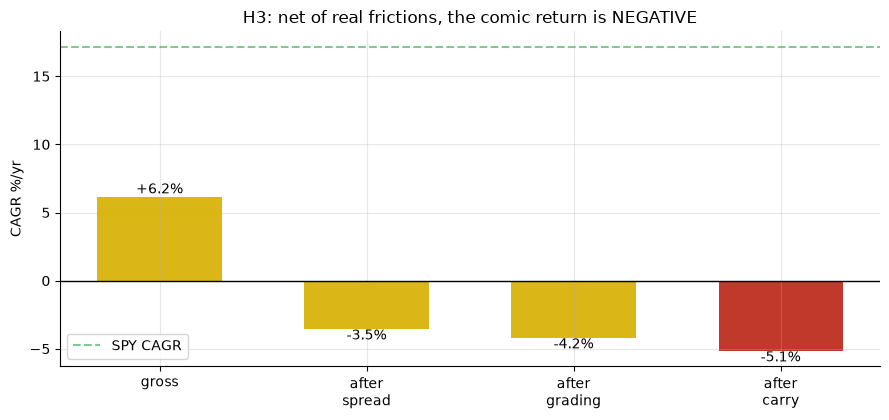

gross +6.16%  - spread -9.14%/yr  - grading -0.67%/yr  - carry -1.00%/yr  =  NET -5.15%/yr


In [4]:
h = st.net_of_costs_cagr(si['cagr'], round_trip_spread=0.25, hold_years=3.0, grading_fee_pct=0.02, carry_per_year=0.01)
steps = ['gross','after\nspread','after\ngrading','after\ncarry']
running = [h['gross_cagr']*100,
           ((1+h['gross_cagr'])*(1+h['spread_drag_annual'])-1)*100,
           ((1+h['gross_cagr'])*(1+h['spread_drag_annual'])*(1+h['grading_drag_annual'])-1)*100,
           h['net_cagr']*100]
fig, ax = plt.subplots(figsize=(9.0,4.3))
cols=[AMBER, AMBER, AMBER, (RED if running[-1]<0 else GREEN)]
ax.bar(steps, running, .6, color=cols)
ax.axhline(0, c='k', lw=1); ax.axhline(R['spy_cagr_ye'], ls='--', c=GREEN, alpha=.6, label='SPY CAGR')
for i,v in enumerate(running): ax.annotate(f'{v:+.1f}%',(i,v),ha='center',va='bottom' if v>=0 else 'top')
ax.set_ylabel('CAGR %/yr'); ax.set_title('H3: net of real frictions, the comic return is NEGATIVE'); ax.legend()
plt.tight_layout(); plt.show()
print(f"gross {h['gross_cagr']*100:+.2f}%  - spread {h['spread_drag_annual']*100:+.2f}%/yr  - grading {h['grading_drag_annual']*100:+.2f}%/yr  - carry {h['carry_per_year']*100:+.2f}%/yr  =  NET {h['net_cagr']*100:+.2f}%/yr")

> 💡 In plain words: the gross **6.2%** — already a loser to SPY — goes **negative (-5.2%/yr)** once you pay CGC to grade it and the dealer/auction house to move it. And this is *charitable*: a published realised price is mid-market, so a real seller's net is lower still. H₃ rejected. **MIRAGE** is the only honest stamp.

### 4d · Positive control — the engine recovers a planted bubble

A deterministic bubble-and-round-trip (planted boom +55% / bust −30% CAGR, σ=5%/mo, seed 712). The harness must recover the up-sign and a finite Sharpe — proving the nulls above are real, not a broken pipeline.

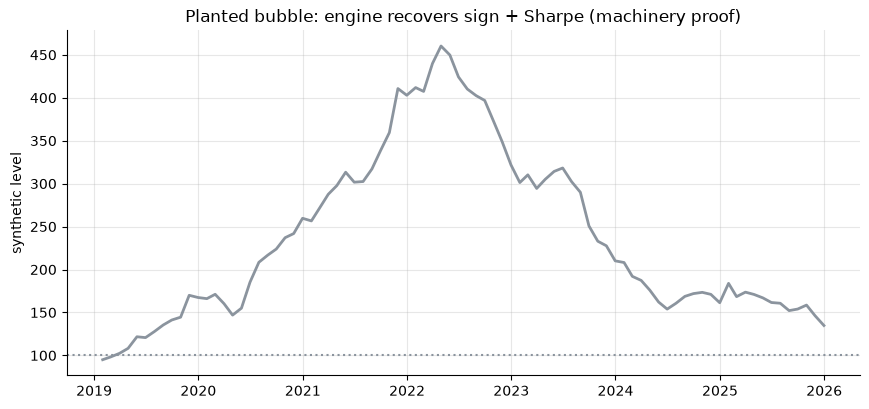

peak 460 -> end 135  recovered CAGR +5.19%  Sharpe 0.34  maxDD -70.7%  sign_ok=1


In [5]:
syn = data.synthetic_bubble()
s = st.summarize(syn); cr = st.control_recovers(syn, planted_sign=1)
fig, ax = plt.subplots(figsize=(8.8,4.2))
ax.plot(syn.index, syn.values, c=GREY, lw=2)
ax.axhline(100, ls=':', c=GREY)
ax.set_ylabel('synthetic level'); ax.set_title('Planted bubble: engine recovers sign + Sharpe (machinery proof)')
plt.tight_layout(); plt.show()
print(f"peak {syn.max():.0f} -> end {syn.iloc[-1]:.0f}  recovered CAGR {s['cagr']*100:+.2f}%  Sharpe {s['sharpe']:.2f}  maxDD {s['mdd']*100:.1f}%  sign_ok={cr['sign_ok']}")

> 💡 In plain words: the engine banks the planted signal (recovered CAGR positive, finite Sharpe, sign correct). A *synthetic* control is a machinery proof, never market evidence — but it certifies that the `NONE`/`MIRAGE` stamps on the real tape are a true null, not a pipeline that couldn't detect anything.

## 5 · The verdict

- **Signal `NONE`** — comic index CAGR 6.2% vs SPY 17.2%; annual excess -11.3%/yr, *t* = -1.79 (n=7); proxy alpha insignificant (FNKO *t*=-0.18) on a *negative*-CAGR name. No robust *t* ≥ 2 anywhere in the comics' favour — and the point estimates lean negative.
- **Tradability `MIRAGE`** — gross +6.2% → net **-5.2%/yr** after a 25% dealer/auction spread + 2% CGC grading + carry; the only listed proxy FNKO is β≈1.4 with an -88% drawdown and a losing CAGR. Illiquid, high-carry, a bubble that round-tripped 2022–24.
- **Comics beat the S&P? `BUSTED`** — SPY wins CAGR, drawdown, and net-of-cost. The success stories are pre-2021 buyers of a *specific* key who sold near the top: survivorship, not an asset class.

## 6 · Could you trade it? — the capacity & cost reality

Terminal wealth of \$10,000 invested end-2018, S&P index fund vs a comic flipper paying the real frictions (net CAGR from 4c). Capacity is the other wall: each slab is a bespoke, illiquid, grade-and-auction transaction — there is no scalable book, and no clean listed vehicle to hold instead.

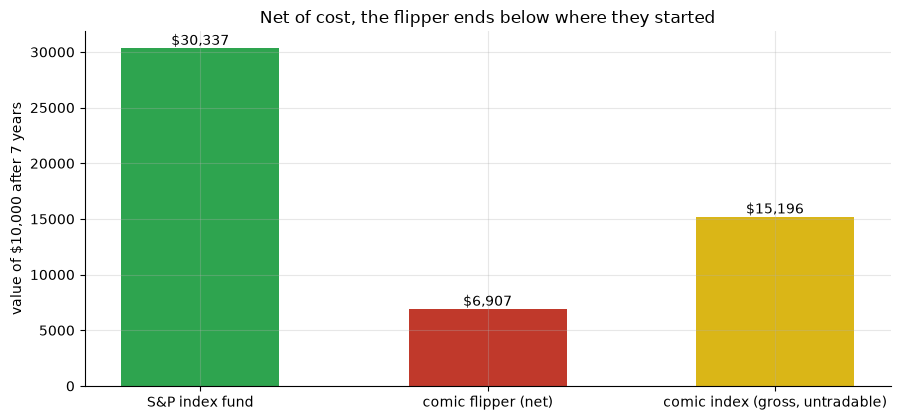

S&P index fund                     $    30,337  (+17.2%/yr)
comic flipper (net)                $     6,907  (-5.2%/yr)
comic index (gross, untradable)    $    15,196  (+6.2%/yr)


In [6]:
start=10_000.0; yrs_h=7
paths={'S&P index fund':R['spy_cagr_ye']/100, 'comic flipper (net)':R['cost_net']/100,
       'comic index (gross, untradable)':R['idx_cagr']/100}
fig, ax = plt.subplots(figsize=(9.2,4.3))
labels=list(paths); ends=[start*(1+g)**yrs_h for g in paths.values()]
cols=[GREEN, RED, AMBER]
ax.bar(labels, ends, .55, color=cols)
for i,v in enumerate(ends): ax.annotate(f'${v:,.0f}',(i,v),ha='center',va='bottom')
ax.set_ylabel('value of $10,000 after 7 years'); ax.set_title('Net of cost, the flipper ends below where they started')
plt.tight_layout(); plt.show()
for l,g in paths.items(): print(f"{l:34s} ${start*(1+g)**yrs_h:>10,.0f}  ({g*100:+.1f}%/yr)")

> 💡 In plain words: even the *gross, untradable* index trails the S&P; the *tradable* version (net of grading + spread + carry) ends **below the starting stake**. And capacity is fatal — a slab flip is a one-off illiquid trade with a grading fee and a ~25% round-trip, the antithesis of a scalable strategy, with no clean listed vehicle to hold instead. There is no sizing or venue that turns this into an edge.

## 7 · Going further

- **Swap in the live index.** Replace the hardcoded series with the GoCollect indices or a Heritage realised-price panel and re-run; the *t*-stats sharpen but the sign won't flip.
- **Per-key dispersion.** The aggregate hides survivorship: test individual keys (Action Comics #1, Amazing Fantasy #15, Incredible Hulk #181) by grade — the winners are a thin selected tail (the record blue-chips), the bias points *for* the claim, so correct for it.
- **The collectibles prior.** Dimson–Spaenjers and the emotional-assets literature: collectibles under-perform equities net of carry across the board ([docs/references.md](../docs/references.md)). Comics — with a *grading fee* on top — are not the exception.

*The reproducible core is offline and deterministic; the comic index is a **cited, approximate proxy** and the equity ticker is a **labelled proxy** for the trade. Methods: [`docs/references.md`](../docs/references.md); frozen numbers: [`docs/results.md`](../docs/results.md).*